In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import json
import sys
sys.path.append("..")
from src.setting import GetInfo, PROJECT_PATH

from sklearn.decomposition import PCA
from scipy.linalg import eigh

In [2]:
ieeg_datapath = 'ieeg_shortWOBS_fs250'
meg_datapath = '/projects/MINDLAB2025_MEG-Auditory_Cognitive_Maps/scratch/APR2020_Block3_SingleTrial_BarbaraNikita'
meg_outpath ='MEG/dataMEG'

os.path.isdir(meg_datapath)
meg_subj_list = [file.replace('_sensor.p', '') for file in os.listdir(meg_outpath) if '_sensor' in file]
print('MEG Subject number : ', len(meg_subj_list))

ieeg_subj_list = [file.replace('_epochs.p', '') for file in os.listdir(ieeg_datapath) if file[-len('epochs.p'):] == 'epochs.p']
print('iEEG Subject number : ', len(ieeg_subj_list))

info_file = ieeg_datapath + f'/{ieeg_subj_list[0]}_info.json'
with open(info_file) as json_data:
    d = json.load(json_data)
    time_ieeg = d['time_epoch']

project_path = '../' + PROJECT_PATH
coord, areas, elect_list, subj_list, regions_ieeg = GetInfo(ieeg_subj_list, data_path=ieeg_datapath, project_path=project_path)
coord=np.array(coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = coord/1000

dt = np.mean(np.diff(time_ieeg))
fs = 1 / dt
f_min = 0.5
f_max = 110
n_frequencies = 86
frequencies = np.geomspace(f_min,f_max,n_frequencies)
bandwidth = [max(0.5,0.20 * freq) for freq in frequencies]

MEG Subject number :  32
iEEG Subject number :  30


In [3]:
out_path = 'out/data'
with open(out_path + '/ieeg_data_mean.p', "rb") as f:
    ieeg_data = pickle.load(f)

with open(out_path + '/data_matched.p', "rb") as f:
    data_matched = pickle.load(f)  

data_matched = data_matched.mean(0).T
ieeg_data = ieeg_data.mean(0).T

In [4]:
out_path = 'out/freq'
with open(out_path + '/expl_var_r_ieeg.p', "rb") as f:
    expl_var_r_ieeg = pickle.load(f)
with open(out_path + '/expl_var_ieeg.p', "rb") as f:
    expl_var_ieeg = pickle.load(f)

with open(out_path + '/expl_var_r_match.p', "rb") as f:
    expl_var_r_meg = pickle.load(f)
with open(out_path + '/expl_var_match.p', "rb") as f:
    expl_var_meg = pickle.load(f)

In [5]:
color_map = plt.cm.Blues(np.linspace(0.5, 1, 5))

In [8]:
frequencies = np.geomspace(f_min,f_max,n_frequencies)
bandwidth = [max(0.5,0.20 * freq) for freq in frequencies]
bandwidth

[0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 0.5,
 np.float64(0.5206019148714384),
 np.float64(0.554707036644498),
 np.float64(0.5910464170668801),
 np.float64(0.6297664245270418),
 np.float64(0.6710230161444262),
 np.float64(0.7149823659362587),
 np.float64(0.7618215341361454),
 np.float64(0.8117291803603601),
 np.float64(0.8649063234943276),
 np.float64(0.9215671513599871),
 np.float64(0.9819398834252268),
 np.float64(1.046267690030225),
 np.float64(1.114809671833174),
 np.float64(1.1878419034204208),
 np.float64(1.2656585452844844),
 np.float64(1.3485730286488047),
 np.float64(1.4369193179114734),
 np.float64(1.5310532557928478),
 np.float64(1.6313539966050474),
 np.float64(1.7382255334162828),
 np.float64(1.852098325261168),
 np.float64(1.973431030951102),
 np.float64(2.102712356468206),
 np.float64(2.2404630233837795),
 np.float64(2.3872378662297016),
 np.float64(2.54362806727

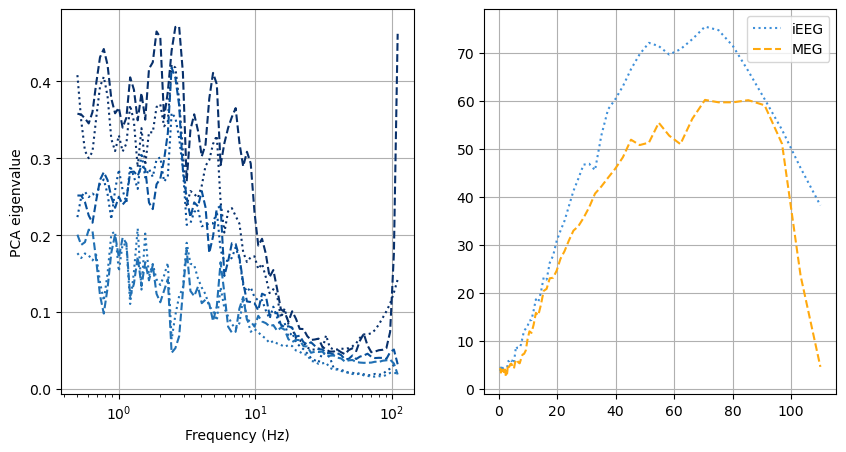

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for x in range(3) :
    ax[0].semilogx(frequencies,expl_var_r_ieeg[:, x], ls=':', c=color_map[4-x])
    ax[0].semilogx(frequencies,expl_var_r_meg[:, x], ls='--', c=color_map[4-x])

ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("PCA eigenvalue")
ax[0].grid(True)

ED = np.sum(expl_var_ieeg, axis=1)**2/np.sum(expl_var_ieeg**2,  axis=1)
ax[1].plot(frequencies, ED, ls=':', label='iEEG')
ax[1].grid(True)

ED = np.sum(expl_var_meg, axis=1)**2/np.sum(expl_var_meg**2,  axis=1)
ax[1].plot(frequencies, ED,ls='--', label='MEG')
ax[1].legend()


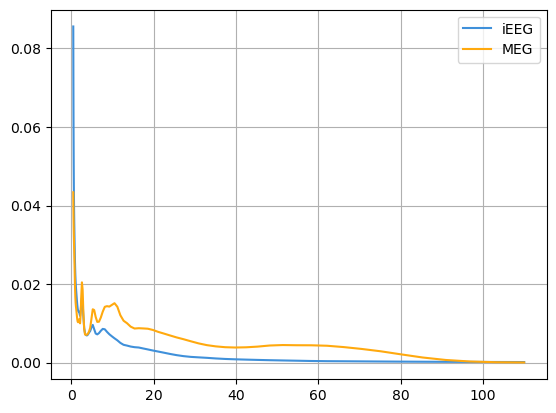

In [7]:
power_ieeg = np.sum(expl_var_ieeg,axis=1)
power_ieeg /= np.sum(power_ieeg)

power_meg = np.sum(expl_var_meg,axis=1)
power_meg /= np.sum(power_meg)

plt.plot(frequencies, power_ieeg, label='iEEG')
plt.plot(frequencies, power_meg, label='MEG')
plt.legend()
plt.grid(True)